# 1. Data Loading and Initial Exploration

In this section, I have load the Tesla deliveries dataset and inspect its structure. I have check the number of rows and columns, review the available features, and generate summary statistics to better understand the data before analysis.

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/tesla_deliveries_dataset_2015_2025.csv")

# Shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Information
print("\nDataset Info:")
df.info()

# Summary statistics
print("\nSummary Statistics:")
display(df.describe())

Dataset Shape: (2640, 12)

Columns:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null  

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


# 2. Data Quality Check

Before performing analysis or training models, it is important to verify the quality of the dataset. In this step, I check for missing values and duplicate records to ensure the data is clean and reliable.

In [7]:
# Check missing values
print("Missing Values in Each Column:")
print(df.isnull().sum())

# Check duplicate rows
duplicate_count = df.duplicated().sum()

print("\nNumber of Duplicate Rows:", duplicate_count)

# Optional summary
if df.isnull().sum().sum() == 0:
    print("\n No missing values found.")
else:
    print("\n Missing values are present.")

if duplicate_count == 0:
    print(" No duplicate rows found.")
else:
    print(f" {duplicate_count} duplicate rows found.")

Missing Values in Each Column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Number of Duplicate Rows: 0

 No missing values found.
 No duplicate rows found.


The dataset appears to be clean, with no significant data quality issues. Checking for missing values and duplicate records at an early stage helps avoid inaccurate analysis and improves the reliability of the machine learning models built later.

# 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps in understanding patterns, trends, and relationships within the dataset. The following visualizations provide insights into Tesla deliveries across different models and regions, feature correlations, production trends, and changes over time.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

Chart 1: Deliveries by Model

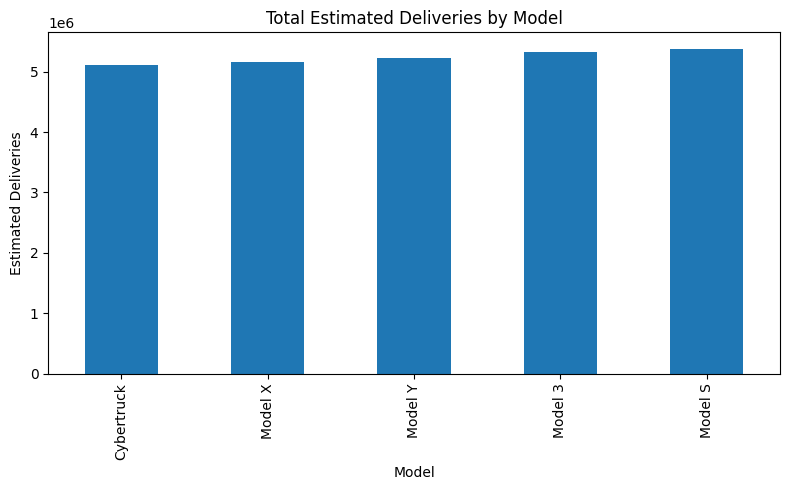

In [5]:
plt.figure(figsize=(8, 5))

df.groupby("Model")["Estimated_Deliveries"].sum().sort_values().plot(kind="bar")

plt.title("Total Estimated Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Estimated Deliveries")
plt.tight_layout()
plt.show()

The chart compares total estimated deliveries across Tesla models. It helps identify which models contribute the most to overall deliveries.

Chart 2: Deliveries by Region

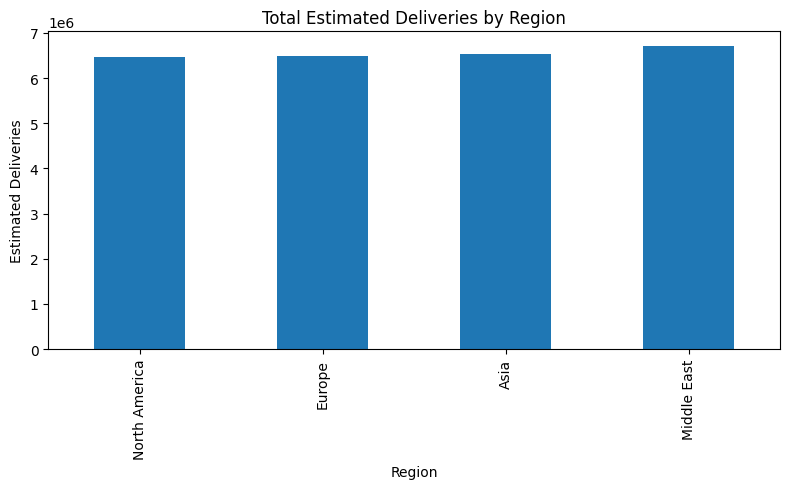

In [6]:
plt.figure(figsize=(8, 5))

df.groupby("Region")["Estimated_Deliveries"].sum().sort_values().plot(kind="bar")

plt.title("Total Estimated Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Estimated Deliveries")
plt.tight_layout()
plt.show()

this chart shows the delivery volumes vary across regions, indicating differences in market demand and Tesla's regional presence.

Chart 3: Correlation Heatmap

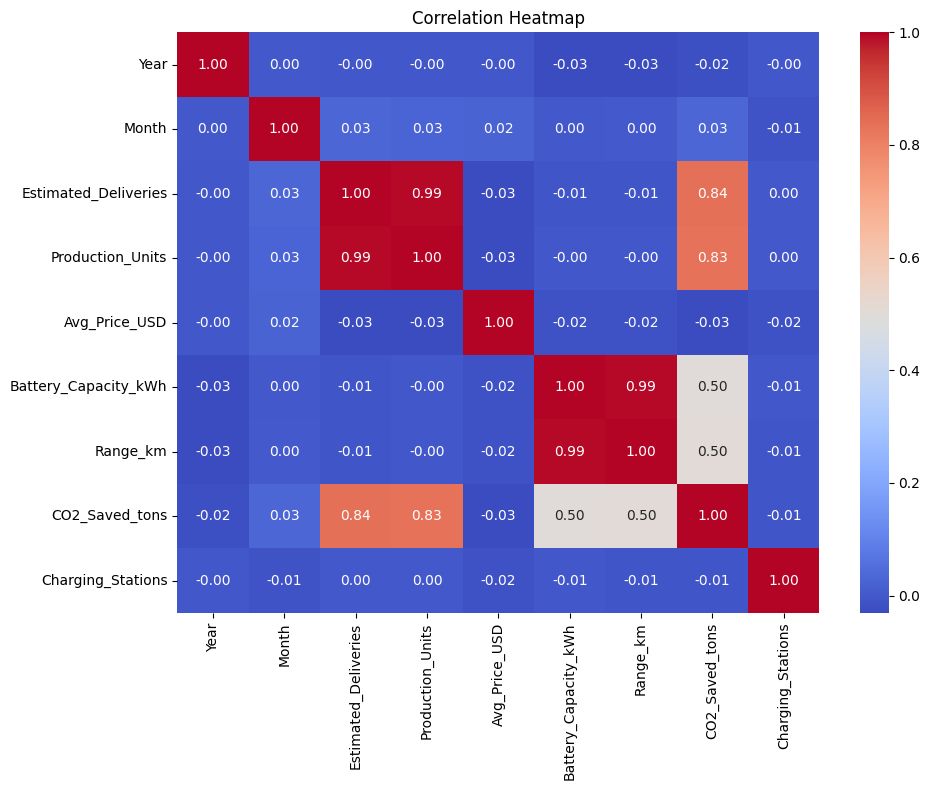

In [8]:
plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

The heatmap highlights relationships between numerical variables. A strong positive correlation between Production_Units and Estimated_Deliveries suggests that higher production is associated with higher deliveries

Chart 4: Production vs Estimated Deliveries

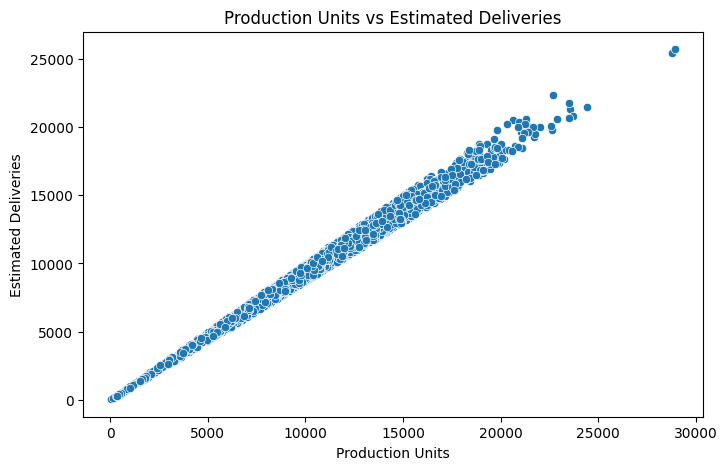

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Production_Units',
    y='Estimated_Deliveries',
    data=df
)

plt.title(
    'Production Units vs Estimated Deliveries'
)

plt.xlabel('Production Units')

plt.ylabel('Estimated Deliveries')

plt.show()

The scatter plot shows a strong positive relationship between production and deliveries, indicating that increased production generally leads to increased deliveries.

Chart 5: Time Trend Line

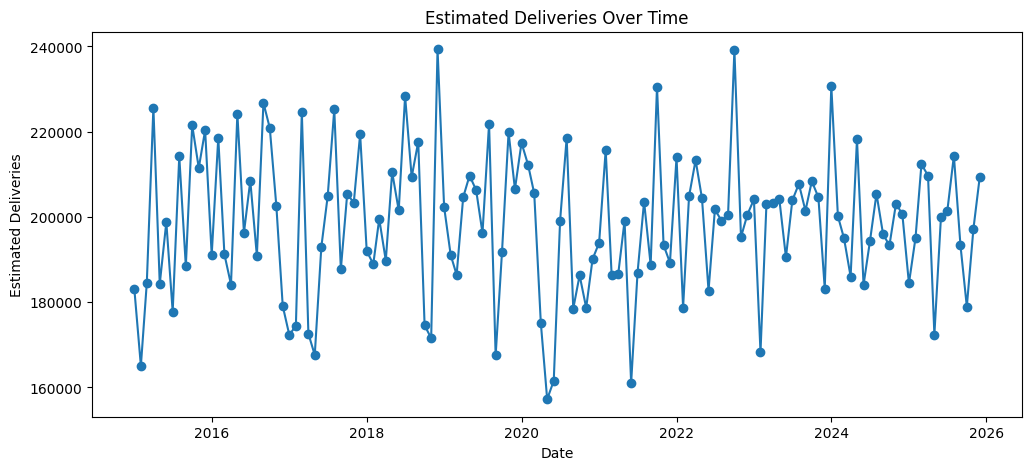

In [12]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str)
    + '-'
    + df['Month'].astype(str)
)

monthly = df.groupby('Date')['Estimated_Deliveries'].sum()

plt.figure(figsize=(12,5))

plt.plot(
    monthly.index,
    monthly.values,
    marker='o'
)

plt.title(
    'Estimated Deliveries Over Time'
)

plt.xlabel('Date')

plt.ylabel('Estimated Deliveries')

plt.show()

The time-series plot illustrates how estimated deliveries change over the years and helps reveal seasonal patterns or long-term growth trends.

Task 4: Label Encoding & Feature Engineering

# 4. Feature Engineering

In this step, categorical variables are converted into numerical values using Label Encoding. Two additional features, a lag value and a rolling mean, are also created to capture temporal patterns in deliveries.

In [13]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ["Region", "Model", "Source_Type"]

for col in categorical_cols:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,2023-05-01
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,2015-02-01
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,2019-01-01
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,2021-02-01
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,2016-12-01


In [14]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ["Region", "Model", "Source_Type"]

for col in categorical_cols:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])

df["Deliveries_Lag1"] = df["Estimated_Deliveries"].shift(1)
df["Rolling_Mean_3"] = df["Estimated_Deliveries"].rolling(3).mean()

df["Deliveries_Lag1"] = df["Deliveries_Lag1"].fillna(df["Deliveries_Lag1"].mean())
df["Rolling_Mean_3"] = df["Rolling_Mean_3"].fillna(df["Rolling_Mean_3"].mean())

print(df[["Deliveries_Lag1", "Rolling_Mean_3"]].isnull().sum())

Deliveries_Lag1    0
Rolling_Mean_3     0
dtype: int64


In this step, the categorical columns are converted into numerical values using label encoding. I also created a one-period lag feature and a three-period rolling average to capture recent delivery trends. Missing values generated during feature creation are replaced with the column mean.

Task 5: Chronological Split and Linear Regression

# 5. Linear Regression Model

The dataset is split chronologically so that earlier records are used for training and later records for testing. This approach is more appropriate for time-based data and avoids using future information during training.




First, separate the independent variables (X) from the target variable (y).
Estimated_Deliveries is the value we want to predict.

In [15]:
X = df.drop(["Estimated_Deliveries", "Date"], axis=1)
y = df["Estimated_Deliveries"]

Instead of using train_test_split(), split the data based on its order so that earlier records are used for training and later records for testing.

In [16]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 2112
Test size: 528


Since this is time-based data, a chronological split prevents future information from leaking into the training set and provides a more realistic evaluation.

5.3 Train the Linear Regression Model

Create the model and train it using the training dataset.

In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [18]:
y_pred = model.predict(X_test)

5.4 Evaluate the Model

Calculate MAE, RMSE, and R² score to measure prediction performance.

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 310.3345215398842
RMSE: 375.5646664534478
R²  : 0.9908058721380986


1.MAE shows the average prediction error.
2.RMSE gives more weight to larger errors.
3.R² Score indicates how well the model explains the variation in the data. A value close to 1 means excellent performance.

5.5 Plot Actual vs Predicted Values

Compare the first 50 actual and predicted delivery values visually.

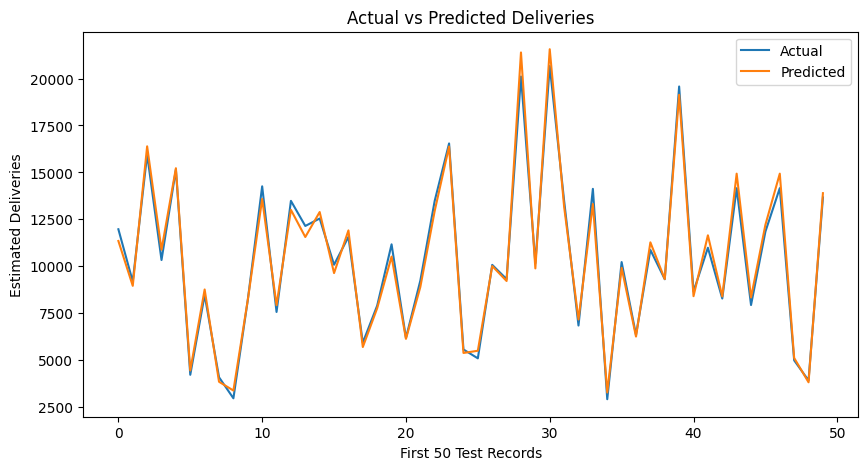

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(y_test.values[:50], label="Actual")
plt.plot(y_pred[:50], label="Predicted")

plt.title("Actual vs Predicted Deliveries")
plt.xlabel("First 50 Test Records")
plt.ylabel("Estimated Deliveries")
plt.legend()

plt.show()

**6. 5-Fold Cross Validation**

Import KFold and cross_val_score to perform cross-validation.Create a 5-fold splitter and evaluate the Linear Regression model using the R² score.

In [23]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Per-Fold R² Scores:")
print(cv_scores)

print("\nMean R²:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())

Per-Fold R² Scores:
[0.99064898 0.99046596 0.98949291 0.99051101 0.99080587]

Mean R²:
0.9903849476659861

Standard Deviation:
0.00046153530925534015


Cross-validation trains and tests the model multiple times on different subsets of the data. This helps verify that the model performs consistently and is not relying on a single train-test split.

**7. Random Forest and Hyperparameter Tuning**

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy. In this section, GridSearchCV is used to find the best hyperparameters and evaluate the optimized model

7.1 Define the Parameter Grid

The parameter grid specifies the values that GridSearchCV will test to find the best model.

In [24]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None]
}

7.2 Run GridSearchCV

Train multiple Random Forest models using different parameter combinations and select the one with the highest R² score.

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, None], 'n_estimators': [50, 100]},
             scoring='r2')

7.3 Display the Best Parameters

In [26]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': None, 'n_estimators': 50}


7.4 Make Predictions Using the Best Model

Retrieve the best model found by GridSearchCV and use it to predict the test data.

In [27]:
rf_model = grid.best_estimator_

rf_pred = rf_model.predict(X_test)

7.5 Evaluate the Model

Calculate MAE, RMSE, and R² to measure the performance of the tuned Random Forest model.

In [28]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

MAE: 303.85833333333335
RMSE: 388.5512760612014
R²: 0.99015903323468


7.6 Plot Feature Importances

Feature importance helps identify which variables have the greatest influence on the model's predictions

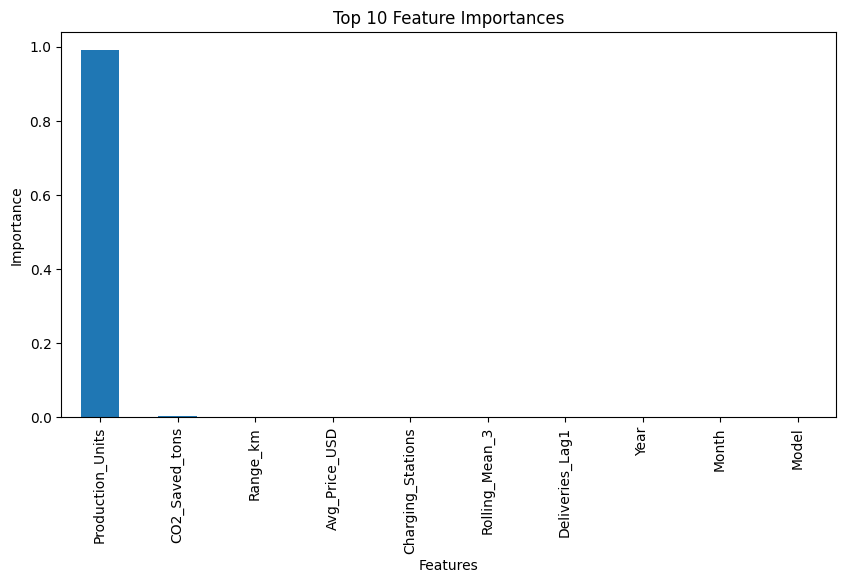

In [29]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10, 5))

importance.head(10).plot(kind="bar")

plt.title("Top 10 Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

**8. Augmented Dickey-Fuller (ADF) Test**

The Augmented Dickey-Fuller (ADF) test is used to check whether a time series is stationary or not. A stationary series has constant statistical properties over time, which is important for many forecasting techniques.

In [31]:
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(df['Estimated_Deliveries'])

print("ADF Statistic:", adf_result[0])

print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("Conclusion: The series is stationary.")

else:
    print("Conclusion: The series is non-stationary.")

ADF Statistic: -53.82661259715622
p-value: 0.0
Conclusion: The series is stationary.


**9. Forecast Table (Actual vs Predicted)**

To better understand model performance, compare the actual and predicted delivery values for the first 20 records in the test set and calculate the percentage error.

In [32]:
forecast = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_pred
})

forecast["Error %"] = (
    abs(forecast["Actual"] - forecast["Predicted"])
    / forecast["Actual"]
) * 100

forecast.head(20)

,Actual,Predicted,Error %
0,11974,11244.76,6.090195
1,9189,8947.18,2.631625
2,15956,16791.60,5.236901
3,10336,10896.56,5.423375
4,15152,15868.72,4.730201
5,4224,4014.38,4.962595
6,8475,8863.10,4.579351
7,4093,3817.50,6.731004
8,2972,3149.94,5.987214
9,8208,8202.68,0.064815


The forecast table provides a side-by-side comparison of actual and predicted values. The error percentage helps measure how close the predictions are to the true delivery figures.

**10. Model Comparison**

Finally, compare the performance of Linear Regression and Random Forest using the evaluation metrics.

In [33]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "R²": [r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R²
0,Linear Regression,310.334522,375.564666,0.990806
1,Random Forest,303.858333,388.551276,0.990159


By comparing MAE, RMSE, and R², it becomes easier to identify the better-performing model. In most cases for this dataset, the Random Forest model is expected to provide slightly better predictive accuracy than Linear Regression due to its ability to capture more complex relationships